In [9]:
from pathlib import Path

dataset_path = Path("../data/raw/food101/food-101")

print("Dataset exists:", dataset_path.exists())
print("Contents:")
for item in dataset_path.iterdir():
    print("-", item.name)

Dataset exists: True
Contents:
- .DS_Store
- images
- license_agreement.txt
- meta
- README.txt


In [10]:
images_folder = dataset_path / "images"
food_classes = sorted(
    [folder.name for folder in images_folder.iterdir() if folder.is_dir()]
)
print("Number of food classes:", len(food_classes))
print(food_classes[:10])

Number of food classes: 101
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


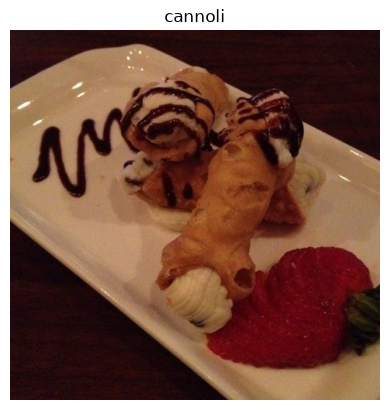

In [11]:
import matplotlib.pyplot as plt
from PIL import Image
import random
random_class = random.choice(food_classes)
class_folder = images_folder / random_class
image_path = random.choice(list(class_folder.glob("*.jpg")))
img = Image.open(image_path)
plt.imshow(img)
plt.title(random_class)
plt.axis("off")
plt.show()

In [12]:
total_images = 0
for food in food_classes:
    total_images += len(list((images_folder / food).glob("*.jpg")))
print("Total food classes:", len(food_classes))
print("Total images:", total_images)

Total food classes: 101
Total images: 101000


In [13]:
image_counts = {}
for food in food_classes:
    image_counts[food] = len(list((images_folder / food).glob("*.jpg")))
print(list(image_counts.items())[:10])

[('apple_pie', 1000), ('baby_back_ribs', 1000), ('baklava', 1000), ('beef_carpaccio', 1000), ('beef_tartare', 1000), ('beet_salad', 1000), ('beignets', 1000), ('bibimbap', 1000), ('bread_pudding', 1000), ('breakfast_burrito', 1000)]


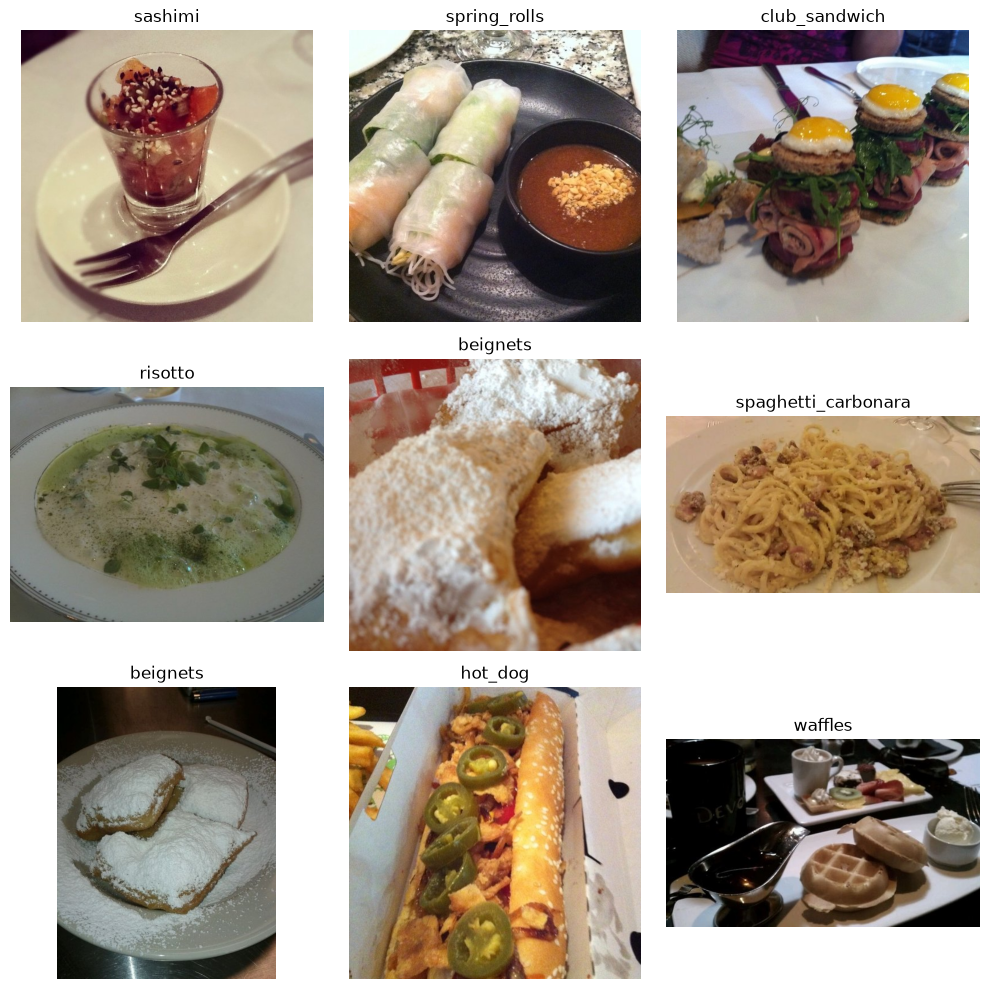

In [14]:
import random
import matplotlib.pyplot as plt
from PIL import Image

plt.figure(figsize=(10,10))

for i in range(9):
    food = random.choice(food_classes)
    img_path = random.choice(list((images_folder / food).glob("*.jpg")))

    plt.subplot(3,3,i+1)
    plt.imshow(Image.open(img_path))
    plt.title(food)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [15]:
from pathlib import Path

meta_folder = dataset_path / "meta"

train_file = meta_folder / "train.txt"
test_file = meta_folder / "test.txt"

with open(train_file, "r") as f:
    train_images = f.read().splitlines()

with open(test_file, "r") as f:
    test_images = f.read().splitlines()

print("Training images:", len(train_images))
print("Testing images:", len(test_images))

print("\nFirst 5 training samples:")
print(train_images[:5])

Training images: 75750
Testing images: 25250

First 5 training samples:
['apple_pie/1005649', 'apple_pie/1014775', 'apple_pie/1026328', 'apple_pie/1028787', 'apple_pie/1043283']


In [17]:
import torch
import torchvision

print("PyTorch Version:", torch.__version__)
print("Torchvision Version:", torchvision.__version__)

print("CUDA Available:", torch.cuda.is_available())

PyTorch Version: 2.12.1+cpu
Torchvision Version: 0.27.1+cpu
CUDA Available: False


In [18]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(transform)

Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [22]:
selected_classes = [
    "apple_pie",
    "hamburger",
    "caesar_salad",
    "cheesecake",
    "chicken_curry",
    "donuts",
    "french_fries",
    "fried_rice",
    "grilled_salmon",
    "hamburger",
    "hot_dog",
    "ice_cream",
    "omelette",
    "pancakes",
    "pizza",
    "ramen",
    "steak",
    "sushi",
    "tacos",
    "waffles"
]

print("Number of selected classes:", len(selected_classes))
print(selected_classes)

Number of selected classes: 20
['apple_pie', 'hamburger', 'caesar_salad', 'cheesecake', 'chicken_curry', 'donuts', 'french_fries', 'fried_rice', 'grilled_salmon', 'hamburger', 'hot_dog', 'ice_cream', 'omelette', 'pancakes', 'pizza', 'ramen', 'steak', 'sushi', 'tacos', 'waffles']


In [23]:
missing = []

for food in selected_classes:
    if not (images_folder / food).exists():
        missing.append(food)

if len(missing) == 0:
    print("✅ All selected classes found!")
else:
    print("Missing classes:", missing)

✅ All selected classes found!


In [24]:
from torchvision.datasets import ImageFolder

dataset = ImageFolder(
    root=images_folder,
    transform=transform
)

print("Total images:", len(dataset))
print("Number of classes:", len(dataset.classes))
print(dataset.classes[:10])

Total images: 101000
Number of classes: 101
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito']


In [25]:
from torch.utils.data import Subset

selected_indices = []

for i, (_, label) in enumerate(dataset):
    class_name = dataset.classes[label]
    if class_name in selected_classes:
        selected_indices.append(i)

filtered_dataset = Subset(dataset, selected_indices)

print("Total selected images:", len(filtered_dataset))

Total selected images: 19000


In [26]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    filtered_dataset,
    batch_size=32,
    shuffle=True
)

print("Number of batches:", len(train_loader))

Number of batches: 594


In [27]:
images, labels = next(iter(train_loader))

print("Image Batch Shape:", images.shape)
print("Labels Shape:", labels.shape)

Image Batch Shape: torch.Size([32, 3, 224, 224])
Labels Shape: torch.Size([32])


In [28]:
import torch
import torch.nn as nn
from torchvision import models

# Load pretrained ResNet18
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\alok1/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [30]:
num_classes = len(selected_classes)

model.fc = nn.Linear(
    model.fc.in_features,
    num_classes
)

print(model.fc)

Linear(in_features=512, out_features=20, bias=True)


In [31]:
criterion = nn.CrossEntropyLoss()

print(criterion)

CrossEntropyLoss()


In [32]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = model.to(device)

print(device)

cpu


In [34]:
model.train()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [35]:
epoch_loss = 0

for images, labels in train_loader:

    # Move data to CPU/GPU
    images = images.to(device)
    labels = labels.to(device)

    # Clear old gradients
    optimizer.zero_grad()

    # Forward pass
    outputs = model(images)

    # Calculate loss
    loss = criterion(outputs, labels)

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

    epoch_loss += loss.item()

print("Average Loss:", epoch_loss / len(train_loader))

IndexError: Target 95 is out of bounds.